### SVM for non-linearly separable data

SVM projects the non-linearly separable data lower dimensions to linearly separable data in higher dimensions in such a way that data points belonging to different classes are allocated to different dimensions.

In the previous example we saw how the simple SVM algorithm can be used to find decision boundary for linearly separable data. However, in the case of non-linearly separable data, such as the one shown in Figure here, a straight line cannot be used as a decision boundary.
In case of non-linearly separable data, the simple SVM algorithm cannot be used. Rather, a modified version of SVM, called Kernel SVM, is used.
Basically, the kernel SVM projects the non-linearly separable data lower dimensions to linearly separable data in higher dimensions in such a way that data points belonging to different classes are allocated to different dimensions. we can simply use Python's Scikit-Learn library to implement and use the kernel SVM.

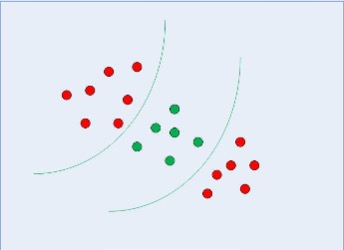

In [1]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
# importing the dataset
colnames = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Class']
irisdata = pd.read_csv("iris.csv", names=colnames)

In [3]:
irisdata.shape

(150, 5)

In [4]:
irisdata.head()

,sepal-length,sepal-width,petal-length,petal-width,Class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
# preprocessing
X = irisdata.drop('Class', axis=1)
y = irisdata['Class']

In [6]:
# train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

To train the kernel SVM, we use the same SVC class of the Scikit-Learn's svm library. The difference lies in the value for the kernel parameter of the SVC class. In the case of the simple SVM we used "linear" as the value for the kernel parameter. Here in this example we use polynomial. In the case of polynomial kernel, you also have to pass a value for the degree parameter of the SVC class. This basically is the degree of the polynomial.

Why Select degree=8?
Higher-degree polynomials can capture complex patterns: A polynomial kernel maps input features into a higher-dimensional space, allowing the model to learn nonlinear decision boundaries.
A degree of 8 means the transformation includes terms up to x⁸, making the decision function more flexible.

In [7]:
# TRAINING WITH POLYNOMIAL KERNEL
from sklearn.svm import SVC
svclassifier = SVC(kernel='poly', degree=8)
svclassifier.fit(X_train, y_train)

SVC(degree=8, kernel='poly')

When to Use a High-Degree Polynomial Kernel?
- If the dataset is highly non-linear and lower-degree polynomials fail to separate the classes effectively.
- If the model has been validated using cross-validation, and degree 8 was found to perform best.
- If feature engineering alone isn’t enough to separate the data in a lower-dimensional space.

Alternative Approaches:
- Try a lower degree (e.g., degree=3 or degree=4) first to reduce complexity and potential overfitting.
- Consider an RBF (Radial Basis Function) kernel (kernel='rbf'), which often performs better for non-linear data without requiring manual degree tuning.

In [8]:
# making predictions
y_pred = svclassifier.predict(X_test)

In [9]:
# evaluating the model
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[11  0  0]
 [ 0  9  1]
 [ 0  1  8]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.89      0.89      0.89         9

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



93% accuracy, only 2 out of 30 data items is misclassified.

If we compare the performance of the different types of kernels we can clearly see that the sigmoid kernel performs the worst. This is due to the reason that sigmoid function returns two values, 0 and 1; therefore, it is more suitable for binary classification problems. However, in our case we had three output classes.
There is no hard and fast rule as to which kernel performs best in every scenario. It is all about testing all the kernels and selecting the one with the best results on your test dataset.

In [10]:
# TRAINING WITH RADIAL BASIS FUNCTION (RBF) KERNEL
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
svclassifier = SVC(kernel='rbf')
svclassifier.fit(X_train, y_train)

y_pred = svclassifier.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[11  0  0]
 [ 0  9  1]
 [ 0  0  9]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.90      1.00      0.95         9

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.96        30
   weighted avg       0.97      0.97      0.97        30



In [11]:
# TRAINING WITH SIGMOID KERNEL
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
svclassifier = SVC(kernel='sigmoid')
svclassifier.fit(X_train, y_train)

y_pred = svclassifier.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 0  0 11]
 [ 0  0 10]
 [ 0  0  9]]
                 precision    recall  f1-score   support

    Iris-setosa       0.00      0.00      0.00        11
Iris-versicolor       0.00      0.00      0.00        10
 Iris-virginica       0.30      1.00      0.46         9

       accuracy                           0.30        30
      macro avg       0.10      0.33      0.15        30
   weighted avg       0.09      0.30      0.14        30

